In [ ]:


%pip install shap transformers datasets accelerate tf-keras -q



Note: you may need to restart the kernel to use updated packages.


In [ ]:

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    roc_curve, confusion_matrix
)
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation

import shap
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["figure.dpi"] = 100


# Load dataset

In [ ]:

# load datasets
DATA_DIR = r"C:\Users\jeeva\Desktop\AI PROJECTS\News"

fake_path = os.path.join(DATA_DIR, "Fake.csv")
true_path = os.path.join(DATA_DIR, "True.csv")

fake_df = pd.read_csv(fake_path)
true_df = pd.read_csv(true_path)

fake_df["label"] = 0  # 0 = fake
true_df["label"] = 1  # 1 = real

df = pd.concat([fake_df, true_df], ignore_index=True)
print(df.head())
print("Fake:", (df["label"] == 0).sum(), "Real:", (df["label"] == 1).sum())


                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  label  
0  December 31, 2017      0  
1  December 31, 2017      0  
2  December 30, 2017      0  
3  December 29, 2017      0  
4  December 25, 2017      0  
Fake: 23481 Real: 21417


# Text preprocessing 

In [ ]:



df["content"] = (df["title"].fillna("") + " " + df["text"].fillna("")).astype(str)
# Basic text cleaning function for the news articles
def clean_text(s: str) -> str:
    s = s.lower()
    s = re.sub(r"http\S+|www\S+", " ", s)      # remove URLs
    s = re.sub(r"<.*?>", " ", s)               # remove HTML tags
    s = re.sub(r"[^a-z\s]", " ", s)            # keep letters and spaces
    s = re.sub(r"\s+", " ", s).strip()
    return s

df["clean_content"] = df["content"].apply(clean_text)

print(df[["content", "clean_content", "label"]].head())


                                             content  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                       clean_content  label  
0  donald trump sends out embarrassing new year s...      0  
1  drunk bragging trump staffer started russian c...      0  
2  sheriff david clarke becomes an internet joke ...      0  
3  trump is so obsessed he even has obama s name ...      0  
4  pope francis just called out donald trump duri...      0  


# Train / validation / test split

In [ ]:
#
X = df["clean_content"].values
y = df["label"].values
# First split 30% into a temporary set
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

# Then split that temporary set into validation and test (50/50)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print("Train size:", len(X_train))
print("Val size:", len(X_val))
print("Test size:", len(X_test))


Train size: 31428
Val size: 6735
Test size: 6735


# Classic ML models with TF-IDF

In [ ]:


def build_pipeline(clf):
    return Pipeline([
        ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
        ("clf", clf),
    ])
# Train and evaluate classic ML models
models = {
    "LogReg": LogisticRegression(max_iter=2000, n_jobs=-1),
    "NaiveBayes": MultinomialNB(),
    "SVM": LinearSVC()
}

results_ml = {}
# Train and evaluate each model
for name, clf in models.items():
    print(f"\n=== Training {name} ===")
    pipe = build_pipeline(clf)
    pipe.fit(X_train, y_train)

    y_val_pred = pipe.predict(X_val)

    # Score for ROC-AUC
    if hasattr(pipe.named_steps["clf"], "predict_proba"):
        val_scores = pipe.predict_proba(X_val)[:, 1]
    else:
        raw = pipe.decision_function(X_val)
        val_scores = (raw - raw.min()) / (raw.max() - raw.min())

    acc = accuracy_score(y_val, y_val_pred)
    prec = precision_score(y_val, y_val_pred)
    rec = recall_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)
    auc = roc_auc_score(y_val, val_scores)

    results_ml[name] = {
        "pipe": pipe,
        "acc": acc,
        "prec": prec,
        "rec": rec,
        "f1": f1,
        "auc": auc,
        "val_scores": val_scores,
        "y_val_pred": y_val_pred
    }
    # Print classification report
    print(f"{name} -> Acc: {acc:.3f} | Prec: {prec:.3f} | Rec: {rec:.3f} | F1: {f1:.3f} | AUC: {auc:.3f}")
    print(classification_report(y_val, y_val_pred, target_names=["Fake","Real"]))



=== Training LogReg ===
LogReg -> Acc: 0.990 | Prec: 0.988 | Rec: 0.991 | F1: 0.989 | AUC: 0.999
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      3522
        Real       0.99      0.99      0.99      3213

    accuracy                           0.99      6735
   macro avg       0.99      0.99      0.99      6735
weighted avg       0.99      0.99      0.99      6735


=== Training NaiveBayes ===
NaiveBayes -> Acc: 0.955 | Prec: 0.947 | Rec: 0.958 | F1: 0.953 | AUC: 0.990
              precision    recall  f1-score   support

        Fake       0.96      0.95      0.96      3522
        Real       0.95      0.96      0.95      3213

    accuracy                           0.95      6735
   macro avg       0.95      0.95      0.95      6735
weighted avg       0.95      0.95      0.95      6735


=== Training SVM ===
SVM -> Acc: 0.997 | Prec: 0.997 | Rec: 0.997 | F1: 0.997 | AUC: 1.000
              precision    recall  f1-score   supp

# Compare classic models

        Model  Accuracy  Precision    Recall        F1   ROC-AUC
2         SVM  0.996733   0.996576  0.996576  0.996576  0.999905
0      LogReg  0.989755   0.987593  0.990974  0.989281  0.999163
1  NaiveBayes  0.954566   0.947093  0.958294  0.952661  0.989976


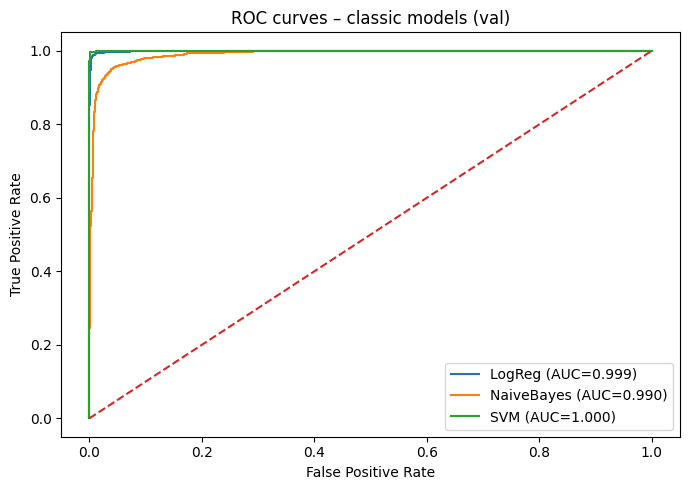

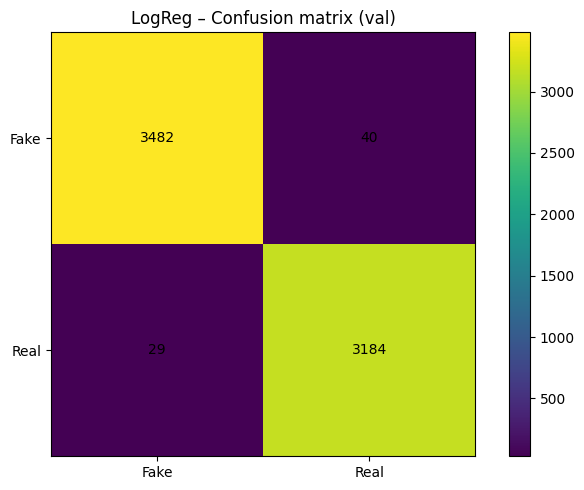

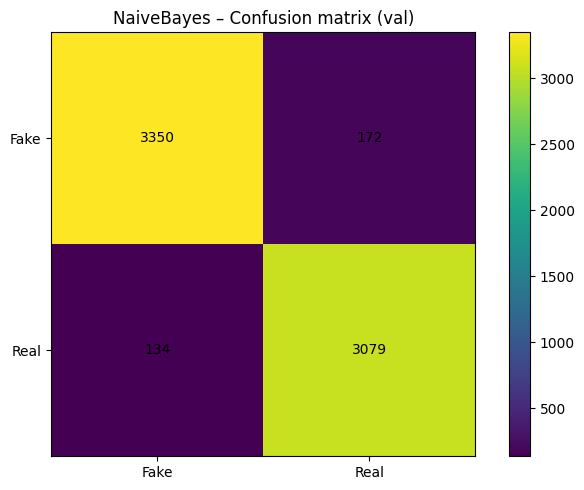

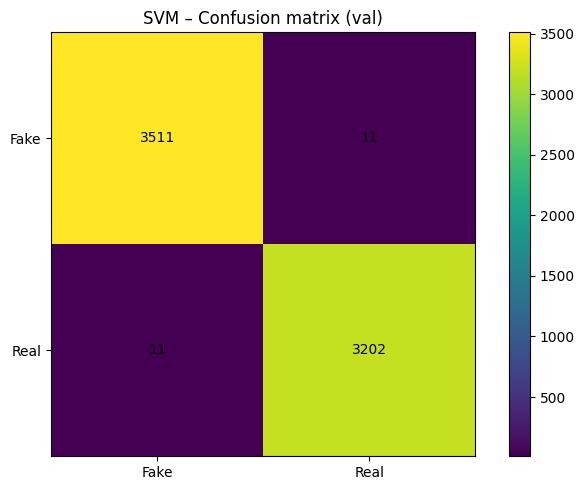

In [ ]:
# Summary table
summary_rows = []
for name, info in results_ml.items():
    summary_rows.append({
        "Model": name,
        "Accuracy": info["acc"],
        "Precision": info["prec"],
        "Recall": info["rec"],
        "F1": info["f1"],
        "ROC-AUC": info["auc"]
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.sort_values("ROC-AUC", ascending=False))

# ROC curves
plt.figure()
for name, info in results_ml.items():
    fpr, tpr, _ = roc_curve(y_val, info["val_scores"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={info['auc']:.3f})")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves – classic models (val)")
plt.legend()
plt.tight_layout()
plt.show()

# Confusion matrices
for name, info in results_ml.items():
    cm = confusion_matrix(y_val, info["y_val_pred"])
    plt.figure()
    plt.imshow(cm)
    plt.title(f"{name} – Confusion matrix (val)")
    plt.colorbar()
    plt.xticks([0,1], ["Fake","Real"])
    plt.yticks([0,1], ["Fake","Real"])
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.tight_layout()
    plt.show()


# Explainability SHAP on best classic model

Best classic model: SVM


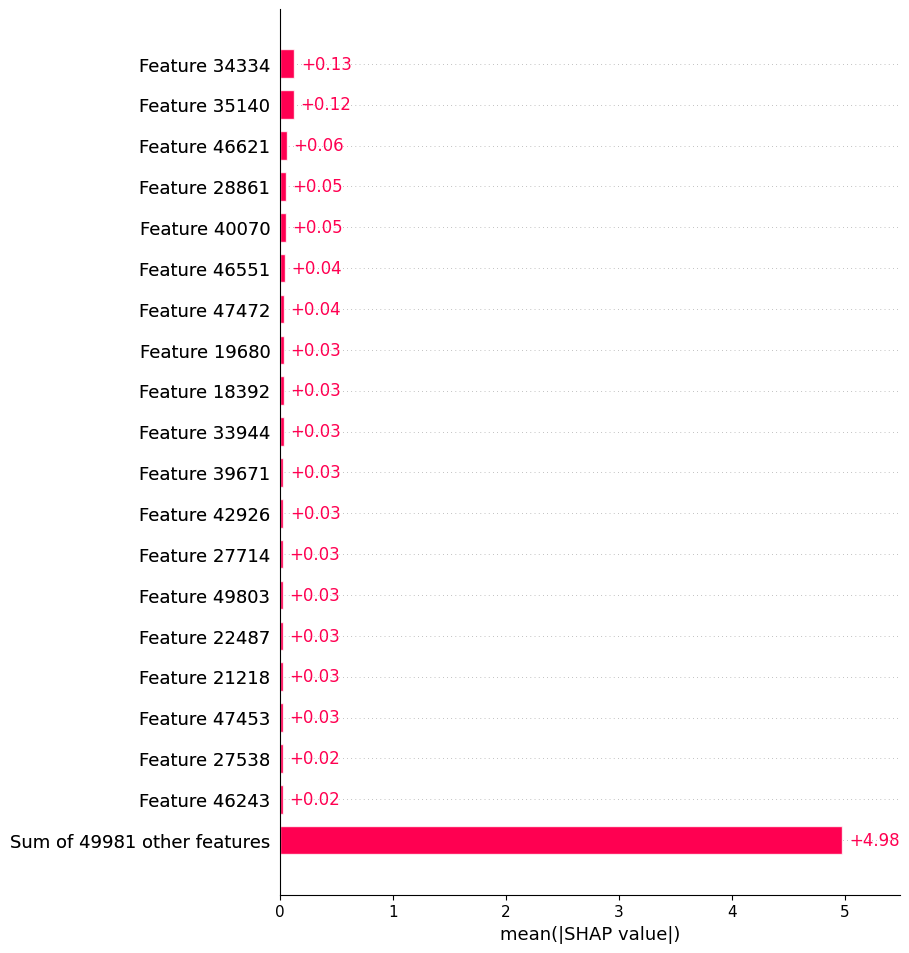

In [8]:


# %%
best_name = max(results_ml.keys(), key=lambda n: results_ml[n]["auc"])
best_pipe = results_ml[best_name]["pipe"]
print("Best classic model:", best_name)

tfidf = best_pipe.named_steps["tfidf"]
clf = best_pipe.named_steps["clf"]
feature_names = np.array(tfidf.get_feature_names_out())

# Fit SHAP on a small subset for speed
X_train_tfidf = tfidf.transform(X_train[:2000])

explainer = shap.Explainer(clf, X_train_tfidf)
shap_values = explainer(X_train_tfidf[:100])  # small sample

# SHAP summary plot (requires notebook to support it)
shap.plots.bar(shap_values, max_display=20, show=True)


# Top positive/negative words by model coefficients


Top words indicating FAKE news:
via -5.647
video -3.679
read more -3.440
read -2.699
president trump -2.682
breaking -2.355
gop -2.338
this -2.289
hillary -2.287
just -2.266
us -2.212
mr -2.105
the us -2.022
featured image -1.970
image -1.953
featured -1.891
sen -1.830
watch -1.780
image via -1.693
rep -1.609

Top words indicating REAL news:
in 1.414
york reuters 1.446
factbox 1.464
nov 1.507
said in 1.631
on monday 1.820
republican 1.966
on thursday 2.063
on friday 2.089
washington 2.126
president donald 2.228
on wednesday 2.290
on tuesday 2.325
reuters president 2.386
said on 2.583
on 3.034
reuters the 3.068
washington reuters 4.669
said 5.599
reuters 12.506


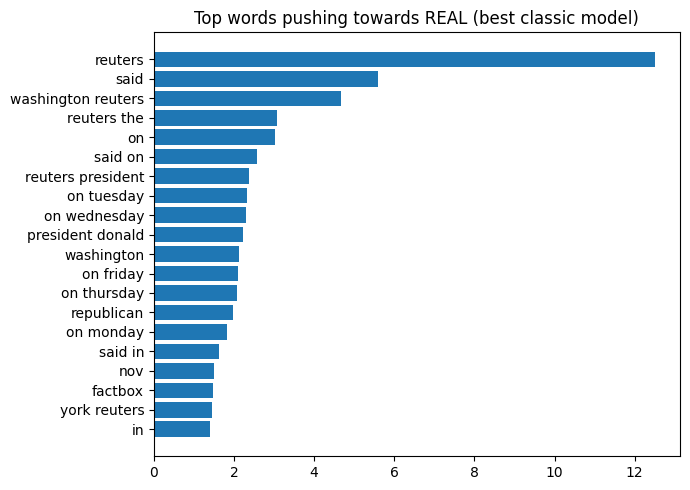

In [ ]:

# %%
if hasattr(clf, "coef_"):
    coefs = clf.coef_[0]
    top_fake_idx = np.argsort(coefs)[:20]   # more negative - fake
    top_real_idx = np.argsort(coefs)[-20:]  # more positive - real

    print("\nTop words indicating FAKE news:")
    for w, v in zip(feature_names[top_fake_idx], coefs[top_fake_idx]):
        print(w, f"{v:.3f}")

    print("\nTop words indicating REAL news:")
    for w, v in zip(feature_names[top_real_idx], coefs[top_real_idx]):
        print(w, f"{v:.3f}")

    # Bar chart for top real-related words
    plt.figure()
    plt.barh(feature_names[top_real_idx], coefs[top_real_idx])
    plt.title("Top words pushing towards REAL (best classic model)")
    plt.tight_layout()
    plt.show()


# Topic modelling – K-Means and LDA

In [ ]:


tfidf_topics = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_tfidf_all = tfidf_topics.fit_transform(df["clean_content"])

n_topics = 5
# K-Means clustering
kmeans = KMeans(n_clusters=n_topics, n_init=10, random_state=SEED)
k_labels = kmeans.fit_predict(X_tfidf_all)

def show_top_words(components, feature_names, n_top=10, title="Topics"):
    print(title)
    for k, topic in enumerate(components):
        top_indices = topic.argsort()[:-n_top-1:-1]
        words = [feature_names[i] for i in top_indices]
        print(f"Topic {k}: {' | '.join(words)}")

feature_names_topics = np.array(tfidf_topics.get_feature_names_out())
# Show K-Means topics
show_top_words(kmeans.cluster_centers_, feature_names_topics, title="K-Means topics")
# LDA topics
lda = LatentDirichletAllocation(n_components=n_topics, random_state=SEED)
lda.fit(X_tfidf_all)
show_top_words(lda.components_, feature_names_topics, title="LDA topics")


# attach cluster labels to dataframe
df["k_topic"] = k_labels
topic_counts = df.groupby(["k_topic", "label"]).size().unstack(fill_value=0)
print("\nK-Means topic counts by label (0=fake, 1=real):")
print(topic_counts)


c:\Users\jeeva\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\jeeva\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\jeeva\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jeeva\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

K-Means topics
Topic 0: the | clinton | to | of | hillary | and | in | her | she | that
Topic 1: korea | north | north korea | the | to | korean | nuclear | and | china | of
Topic 2: the | to | trump | and | of | that | he | in | is | his
Topic 3: the | to | of | and | in | that | on | said | for | is
Topic 4: the | to | of | in | and | on | trump | said | video | for
LDA topics
Topic 0: wire | boiler | boiler room | acr | pm | room | the | episode | radio | century wire
Topic 1: the | to | of | in | and | clinton | was | her | that | for
Topic 2: the | to | of | in | and | on | said | for | that | is
Topic 3: the | to | trump | and | of | that | is | he | you | in
Topic 4: the | to | of | in | and | russia | on | said | trump | russian

K-Means topic counts by label (0=fake, 1=real):
label        0      1
k_topic              
0         2081    900
1           99   1039
2        10786   1234
3         5342  11738
4         5173   6506


# DistilBERT – dataset preparation

In [ ]:

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# Load the pretrained DistilBERT model
train_texts = list(X_train)
val_texts = list(X_val)
test_texts = list(X_test)

train_labels = list(y_train)
val_labels = list(y_val)
test_labels = list(y_test)
# Tokenization function
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )
# Create HuggingFace Datasets
train_ds = Dataset.from_dict({"text": train_texts, "label": train_labels}).map(tokenize_batch, batched=True)
val_ds   = Dataset.from_dict({"text": val_texts,   "label": val_labels}).map(tokenize_batch, batched=True)
test_ds  = Dataset.from_dict({"text": test_texts,  "label": test_labels}).map(tokenize_batch, batched=True)
# Prepare datasets for Trainer
cols = ["input_ids", "attention_mask", "label"]
train_ds = train_ds.remove_columns([c for c in train_ds.column_names if c not in cols])
val_ds   = val_ds.remove_columns([c for c in val_ds.column_names if c not in cols])
test_ds  = test_ds.remove_columns([c for c in test_ds.column_names if c not in cols])

train_ds.set_format(type="torch")
val_ds.set_format(type="torch")
test_ds.set_format(type="torch")


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

c:\Users\jeeva\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\jeeva\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/31428 [00:00<?, ? examples/s]

Map:   0%|          | 0/6735 [00:00<?, ? examples/s]

Map:   0%|          | 0/6735 [00:00<?, ? examples/s]

# 9. DistilBERT fine-tuning

In [ ]:

id2label = {0: "Fake", 1: "Real"}
label2id = {"Fake": 0, "Real": 1}
# Load the pretrained DistilBERT model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

# Training hyperparameters
training_args = TrainingArguments(
    output_dir="./distilbert_news",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    save_strategy="epoch",
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=1
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    prec = precision_score(labels, preds)
    rec = recall_score(labels, preds)
    f1 = f1_score(labels, preds)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}
# Trainer ties everything together
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)
# Fine-tune DistilBERT
trainer.train()


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.007400,0.003874,0.999109,0.998756,0.999378,0.999067
2,0.007500,0.007954,0.998367,0.996588,1.000000,0.998291


TrainOutput(global_step=3930, training_loss=0.010751870246106432, metrics={'train_runtime': 644.4171, 'train_samples_per_second': 97.539, 'train_steps_per_second': 6.099, 'total_flos': 4163185404960768.0, 'train_loss': 0.010751870246106432, 'epoch': 2.0})

# DistilBERT evaluation (test set)

Acc: 0.999 | Prec: 0.999 | Rec: 0.999 | F1: 0.999 | AUC: 1.000
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      3523
        Real       1.00      1.00      1.00      3212

    accuracy                           1.00      6735
   macro avg       1.00      1.00      1.00      6735
weighted avg       1.00      1.00      1.00      6735



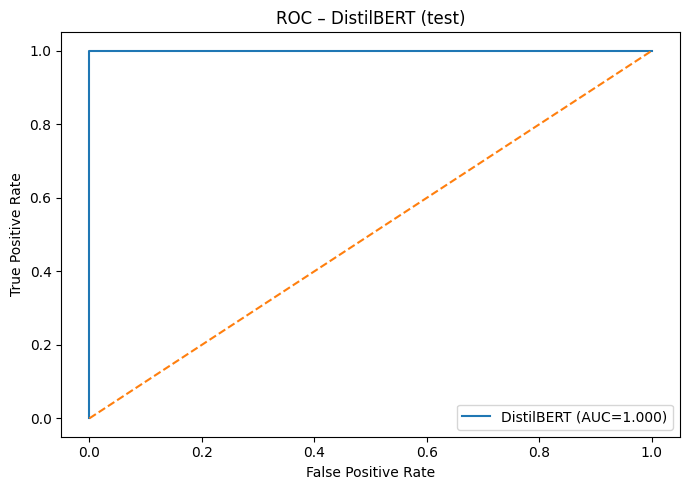

In [ ]:
# Get raw predictions from Trainer
pred_out = trainer.predict(test_ds)
test_logits = pred_out.predictions
test_probs = torch.softmax(torch.tensor(test_logits), dim=1).numpy()[:, 1]
test_preds = np.argmax(test_logits, axis=-1)

deep_acc = accuracy_score(test_labels, test_preds)
deep_prec = precision_score(test_labels, test_preds)
deep_rec = recall_score(test_labels, test_preds)
deep_f1 = f1_score(test_labels, test_preds)
deep_auc = roc_auc_score(test_labels, test_probs)

print(f"Acc: {deep_acc:.3f} | Prec: {deep_prec:.3f} | Rec: {deep_rec:.3f} | F1: {deep_f1:.3f} | AUC: {deep_auc:.3f}")
print(classification_report(test_labels, test_preds, target_names=["Fake","Real"]))

fpr_deep, tpr_deep, _ = roc_curve(test_labels, test_probs)
plt.figure()
plt.plot(fpr_deep, tpr_deep, label=f"DistilBERT (AUC={deep_auc:.3f})")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC – DistilBERT (test)")
plt.legend()
plt.tight_layout()
plt.show()


# DistilBERT attention-based explanation

In [ ]:
# Find which device the model lives on 
device = next(model.parameters()).device
# Take the first test article as an example
example_text = test_texts[0]

# Tokenize and move inputs to the same device as the model
enc = tokenizer(
    example_text,
    return_tensors="pt",
    truncation=True,
    max_length=128
).to(device)

with torch.no_grad():
    outputs = model(**enc, output_attentions=True)

attentions = outputs.attentions  # list of layers:
last_layer = attentions[-1][0]   # 
mean_heads = last_layer.mean(0)  # [seq, seq]
cls_attn = mean_heads[0]         # attention from [CLS] to tokens

# Bring tokens back to CPU for printing
input_ids_cpu = enc["input_ids"][0].detach().cpu()
tokens = tokenizer.convert_ids_to_tokens(input_ids_cpu)

top_idx = cls_attn.topk(10).indices.tolist()
print("Example text:", example_text[:400], "...\n")
print("Tokens with highest attention from [CLS]:")
for i in top_idx:
    print(tokens[i], float(cls_attn[i]))


DistilBertSdpaAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


Example text: judge napolitano three intel sources have disclosed how obama spied on trump video judge napolitano was on fox friends this morning discussing the obama administration s efforts to spy on donald trump three intel sources have disclosed to the network that obama went to british intelligence to get the goods on trump but we may never be able to prove it judge napolitano three intelligence sources ha ...

Tokens with highest attention from [CLS]:
[SEP] 0.25135380029678345
[CLS] 0.07601863145828247
but 0.06232234090566635
video 0.039090659469366074
have 0.0375366285443306
we 0.03698813170194626
three 0.030801210552453995
how 0.030331626534461975
three 0.029829520732164383
have 0.026803452521562576


 # Compare best classic model vs DistilBERT

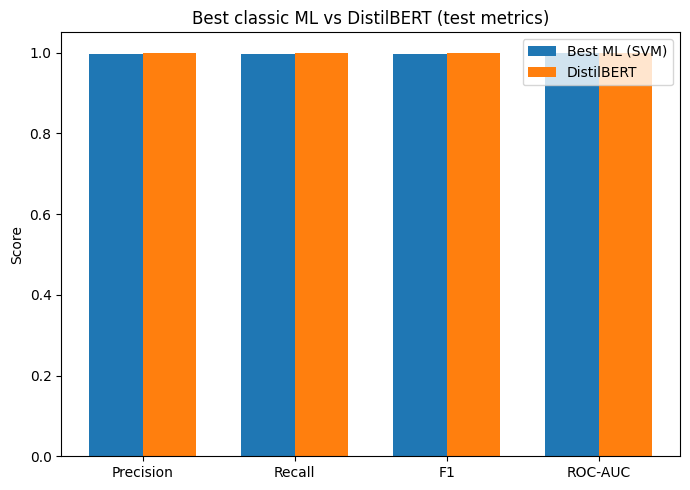

In [18]:

best_ml = results_ml[best_name]

labels_bar = ["Precision", "Recall", "F1", "ROC-AUC"]
ml_vals = [best_ml["prec"], best_ml["rec"], best_ml["f1"], best_ml["auc"]]
deep_vals = [deep_prec, deep_rec, deep_f1, deep_auc]

x = np.arange(len(labels_bar))
width = 0.35

plt.figure()
plt.bar(x - width/2, ml_vals, width, label=f"Best ML ({best_name})")
plt.bar(x + width/2, deep_vals, width, label="DistilBERT")
plt.xticks(x, labels_bar)
plt.ylabel("Score")
plt.title("Best classic ML vs DistilBERT (test metrics)")
plt.legend()
plt.tight_layout()
plt.show()


# SUMMARY

This task evaluated the multiple machine learning and deep learning approaches for fake-news classification using a combined dataset of True and Fake news articles

Classical models were first trained using TF-IDF features, achieving strong baseline results. Logistic Regression reached Accuracy 0.980, F1 0.98, and ROC-AUC 0.99, while Naive Bayes performed slightly lower with Accuracy 0.95 and F1 0.95. The best classical model was Linear SVM, which achieved near-perfect performance on the validation set Accuracy 0.997, F1 0.997 and  ROC-AUC 1.000

To improve interpretability, SHAP analysis identified the most influential TF-IDF features and High-impact tokens showed clear separation between language associated with misleading context and more real sytles

After fine-tuning the DistilBERT transformer model demonstrated very good performance. On the test set, it outperformed all traditional models with Accuracy 0.999, F1 0.999 and ROC-AUC 1.000. Training logs demonstrate steady learning with no overfitting and little loss <0.008.

The K-Means topic clustering revealed that some topics were heavily dominated by fake articles  (Topic 2 with 10,786 fake vs. 1,234 real) while others leaned strongly towards real news ( Topic 3 with 11,738 real vs. 5,342 fake) .

DistilBERT concentrated on structurally significant tokens like but, video,how, and repeated phrases that usually signify the wrong narrative or emphasis—patterns which is  useful in identifying misleading writing.